In [18]:
import sys, os; sys.path.append(os.path.dirname(os.getcwd())) 

from mpl_toolkits import mplot3d

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
from tqdm import tqdm
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn.utils.validation import check_is_fitted
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import wishart

from pyfrechet.metric_spaces import MetricData, Sphere
from matplotlib.cm import get_cmap
from matplotlib.patches import Ellipse

import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Hypersphere 

In [9]:
# read hyp_points.csv
import sys, os
import pandas as pd
hyp_points = pd.read_csv('/Users/Diego/Desktop/Codigo/repo_edu_pyfrechet/pyfrechet/simulations_H2/dibujo/H2_dibujo_repst200_kappa200.csv')
hyp_points.drop(columns = ['Unnamed: 0'], inplace = True)
#name columns 1, 2 and 4 as V1, V2 and V3
hyp_points.columns = ['t', 'V1', 'V2', 'V3']

In [10]:
hyp_points

,t,V1,V2,V3
0,-0.581587,1.191169,-0.516934,-0.389439
1,-0.581587,1.197962,-0.368947,-0.546800
2,-0.581587,1.129038,-0.382858,-0.357975
3,-0.581587,1.158325,-0.432023,-0.393793
4,-0.581587,1.176782,-0.428947,-0.448130
...,...,...,...,...
995,0.581587,1.125046,0.327990,0.397683
996,0.581587,1.177490,0.463381,0.414439
997,0.581587,1.135694,0.415146,0.342717
998,0.581587,1.165849,0.424265,0.423323


In [117]:
# read hyp_points.csv
import sys, os
import pandas as pd
hyp_points = pd.read_csv(os.path.join(os.getcwd(),'simulations_H2', 'hyp_points.csv') )
hyp_points.drop(columns = ['Unnamed: 0'], inplace = True)
#name columns 1, 2 and 4 as V1, V2 and V3
hyp_points.columns = ['t', 'V1', 'V2', 'V3']

In [5]:
# read hyp_points.csv
import sys, os
import pandas as pd
hyp_points = pd.read_csv('/Users/Diego/Desktop/Codigo/repo_edu_pyfrechet/pyfrechet/simulations_H2/data/H2_samp10_N50_kappa200.csv')
hyp_points.drop(columns = ['Unnamed: 0'], inplace = True)
#name columns 1, 2 and 4 as V1, V2 and V3
hyp_points.columns = ['t', 'V1', 'V2', 'V3']

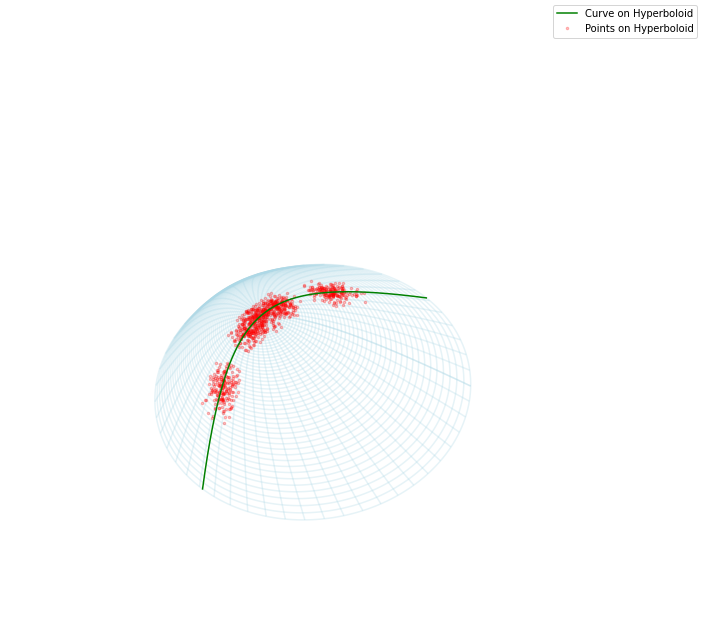

In [4]:
#For hyperboloid
u = np.linspace(0, 1, 1000)
v = np.linspace(0, 2*np.pi, 1000)

u, v = np.meshgrid(u, v)

x_grid = np.cosh(np.abs(u))
y_grid = np.sinh(np.abs(u)) * np.sign(u) * np.cos(v)
z_grid = np.sinh(np.abs(u)) * np.sign(u) * np.sin(v)

# Define the parameter theta
theta = np.linspace(-1, 1, 10000)

# Generate 10 random unit vectors in R2
mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2

fig=plt.figure()
fig.set_size_inches(12, 10)
ax=plt.axes(projection='3d', computed_zorder=False)

x_curve = np.cosh(np.abs(theta))
y_curve = np.sinh(np.abs(theta)) * np.sign(theta) * mu[0]
z_curve = np.sinh(np.abs(theta)) * np.sign(theta) * mu[1]
ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)
# ax.plot_surface(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)

ax.plot(x_curve, y_curve, z_curve, color='green', label='Curve on Hyperboloid', zorder = 1)

# Centers
ax.plot(hyp_points['V1'], hyp_points['V2'], hyp_points['V3'], color='red', marker = '.', lw = 0, markersize = 5, label='Points on Hyperboloid', alpha = 0.25, zorder = 0)

#ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)

ax.view_init(elev=15, azim=-10, roll = 0)
ax.grid(False)
ax.set_axis_off()
fig.legend()
plt.show()

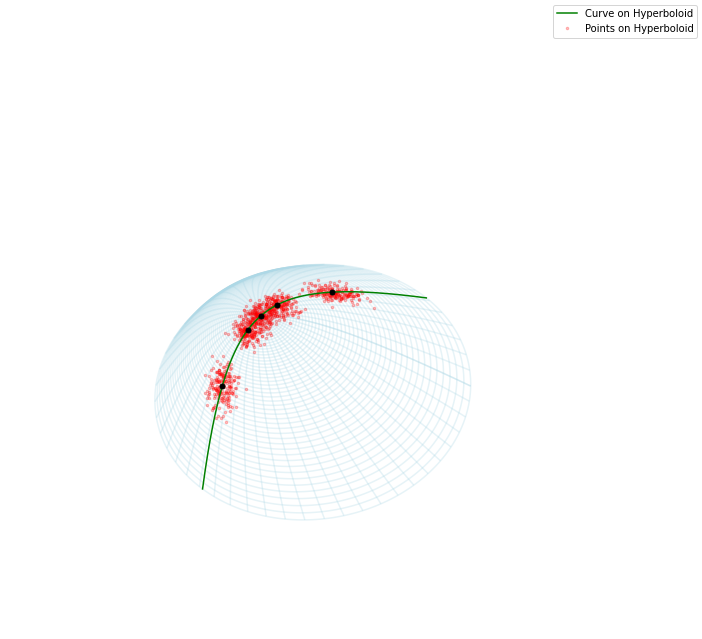

In [17]:
#For hyperboloid
u = np.linspace(0, 1, 1000)
v = np.linspace(0, 2*np.pi, 1000)

u, v = np.meshgrid(u, v)

x_grid = np.cosh(np.abs(u))
y_grid = np.sinh(np.abs(u)) * np.sign(u) * np.cos(v)
z_grid = np.sinh(np.abs(u)) * np.sign(u) * np.sin(v)

# Define the parameter theta
theta = np.linspace(-1, 1, 10000)

# Generate 10 random unit vectors in R2
mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2

fig=plt.figure()
fig.set_size_inches(12, 10)
ax=plt.axes(projection='3d', computed_zorder=False)

x_curve = np.cosh(np.abs(theta))
y_curve = np.sinh(np.abs(theta)) * np.sign(theta) * mu[0]
z_curve = np.sinh(np.abs(theta)) * np.sign(theta) * mu[1]
ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)
# ax.plot_surface(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)

ax.plot(x_curve, y_curve, z_curve, color='green', label='Curve on Hyperboloid', zorder = 1)

# Centers
ax.plot(hyp_points['V1'], hyp_points['V2'], hyp_points['V3'], color='red', marker = '.', lw = 0, markersize = 5, label='Points on Hyperboloid', alpha = 0.25, zorder = 0)

ax.plot(np.cosh(0.8), np.sinh(0.8) * mu[0], np.sinh(0.8) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0.45), np.sinh(0.45) * mu[0], np.sinh(0.45) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0), np.sinh(0) * mu[0], np.sinh(0) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0.45), -np.sinh(0.45) * mu[0], -np.sinh(0.45) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0.8), -np.sinh(0.8) * mu[0], -np.sinh(0.8) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
#ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)

ax.view_init(elev=15, azim=-10, roll = 0)
ax.grid(False)
ax.set_axis_off()
fig.legend()
fig.savefig(os.getcwd() + '/simulations_H2/dibujo/hyperboloid_curve_two.pdf', bbox_inches='tight', format='pdf', transparent=True)
plt.show()

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_17483/3080002807.py:49: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


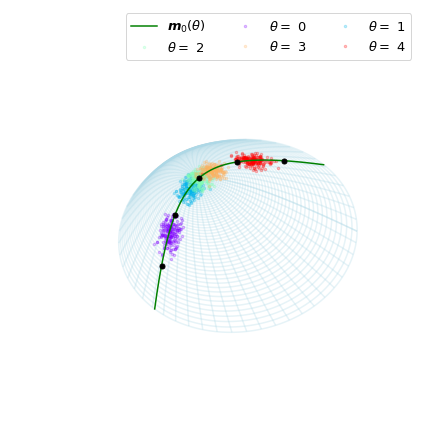

In [6]:
#For hyperboloid
reorder = lambda l, nc: sum((l[i::nc] for i in range(nc)), [])
u = np.linspace(0, 1, 1000)
v = np.linspace(0, 2*np.pi, 1000)

u, v = np.meshgrid(u, v)

x_grid = np.cosh(np.abs(u))
y_grid = np.sinh(np.abs(u)) * np.sign(u) * np.cos(v)
z_grid = np.sinh(np.abs(u)) * np.sign(u) * np.sin(v)

# Define the parameter theta
theta = np.linspace(-1, 1, 10000)

# Generate 10 random unit vectors in R2
mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2

fig=plt.figure( constrained_layout=True)
fig.set_size_inches(6, 6)
ax = plt.axes(projection='3d', computed_zorder=False)
# ax = fig.add_subplot(111, projection='3d', computed_zorder=False)
x_curve = np.cosh(np.abs(theta))
y_curve = np.sinh(np.abs(theta)) * np.sign(theta) * mu[0]
z_curve = np.sinh(np.abs(theta)) * np.sign(theta) * mu[1]
ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)
# ax.plot_surface(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)

ax.plot(x_curve, y_curve, z_curve, color='green', label=r'$\boldsymbol{m}_0(\theta)$', zorder = 1)

cmap = plt.cm.rainbow

# Centers
for i in range(5):
    color = cmap(i/4)
    ax.plot(hyp_points['V1'][i*200:(i+1)*200], hyp_points['V2'][i*200:(i+1)*200], hyp_points['V3'][i*200:(i+1)*200], marker = '.', color = color, lw = 0, markersize = 5, label= f'$\\theta=$ {i}', alpha = 0.25, zorder = 0)
  
ax.plot(np.cosh(0.8), np.sinh(0.8) * mu[0], np.sinh(0.8) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0.45), np.sinh(0.45) * mu[0], np.sinh(0.45) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0), np.sinh(0) * mu[0], np.sinh(0) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0.45), -np.sinh(0.45) * mu[0], -np.sinh(0.45) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0.8), -np.sinh(0.8) * mu[0], -np.sinh(0.8) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
#ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)

ax.set_xticks([])
ax.set_yticks([])
ax.view_init(elev=15, azim=-10, roll = 0)
ax.grid(False)
ax.set_axis_off()
fig.tight_layout()
# fig.subplots_adjust(top=1, bottom=0, left=-1, right=1)
h, l = ax.get_legend_handles_labels()
ax.legend(reorder(h, 3), [label for label in reorder(l, 3)], ncol=3, loc='upper right', fontsize=13)
fig.savefig(os.getcwd() + '/simulations_H2/dibujo/hyperboloid_curve_two.pdf', bbox_inches='tight', format='pdf', transparent=True)
plt.show()

In [20]:
os.getcwd() + '/simulations_H2/dibujo'

'/Users/Diego/Desktop/Codigo/repo_edu_pyfrechet/pyfrechet/simulations_H2/dibujo'

In [3]:
reorder = lambda l, nc: sum((l[i::nc] for i in range(nc)), [])

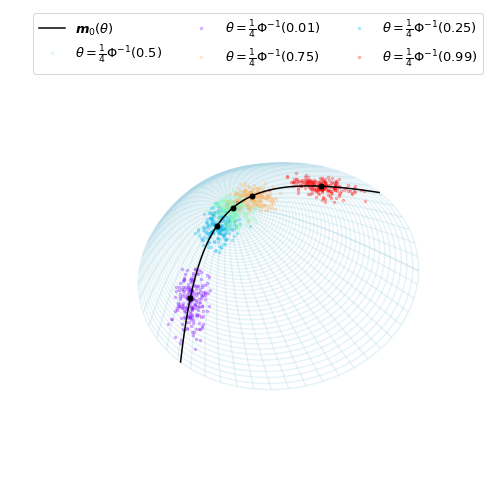

In [20]:
#For hyperboloid
u = np.linspace(0, .8, 1000)
v = np.linspace(0, 2*np.pi, 1000)

u, v = np.meshgrid(u, v)

x_grid = np.cosh(np.abs(u))
y_grid = np.sinh(np.abs(u)) * np.sign(u) * np.cos(v)
z_grid = np.sinh(np.abs(u)) * np.sign(u) * np.sin(v)

# Define the parameter theta
theta = np.linspace(-.8, .8, 10000)

# Generate 10 random unit vectors in R2
mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2

fig=plt.figure()
fig.set_size_inches(7, 7)
ax = plt.axes(projection='3d', computed_zorder=False)
# ax = fig.add_subplot(111, projection='3d', computed_zorder=False)
x_curve = np.cosh(np.abs(theta))
y_curve = np.sinh(np.abs(theta)) * np.sign(theta) * mu[0]
z_curve = np.sinh(np.abs(theta)) * np.sign(theta) * mu[1]
ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)
# ax.plot_surface(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)

ax.plot(x_curve, y_curve, z_curve, color='black', label=r'$\boldsymbol{m}_0(\theta)$', zorder = 1)

cmap = plt.cm.rainbow

# Centers
for i in range(5):
    color = cmap(i/4)
    if i == 0:
        p = 0.01
    elif i == 1:
        p = 0.25
    elif i == 2:
        p = 0.5
    elif i == 3:
        p = 0.75
    else:
        p = 0.99
    ax.plot(hyp_points['V1'][i*200:(i+1)*200], hyp_points['V2'][i*200:(i+1)*200], hyp_points['V3'][i*200:(i+1)*200], marker = '.', color = color, lw = 0, markersize = 5, label= f'$\\theta=\\frac{{1}}{{4}} \\Phi^{{-1}}({p})$', alpha = 0.25, zorder = 0)
  
ax.plot(np.cosh(0.5815870), np.sinh(0.5815870) * mu[0], np.sinh(0.5815870) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0.1686224), np.sinh(0.1686224) * mu[0], np.sinh(0.1686224) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0), np.sinh(0) * mu[0], np.sinh(0) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0.1686224), -np.sinh(0.1686224) * mu[0], -np.sinh(0.1686224) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0.5815870), -np.sinh(0.5815870) * mu[0], -np.sinh(0.5815870) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
#ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)

ax.view_init(elev=15, azim=-10, roll = 0)
ax.grid(False)
ax.set_axis_off()
fig.tight_layout()
# fig.subplots_adjust(top=1, bottom=0, left=-1, right=1)
h, l = ax.get_legend_handles_labels()
ax.legend(reorder(h, 3), [label for label in reorder(l, 3)], ncol=3, loc='upper right', fontsize=13 #, columnspacing=1
)
fig.savefig(os.getcwd() + '/simulations_H2/dibujo/hyperboloid_curve_one.pdf', bbox_inches='tight', format='pdf', transparent=True)
plt.show()

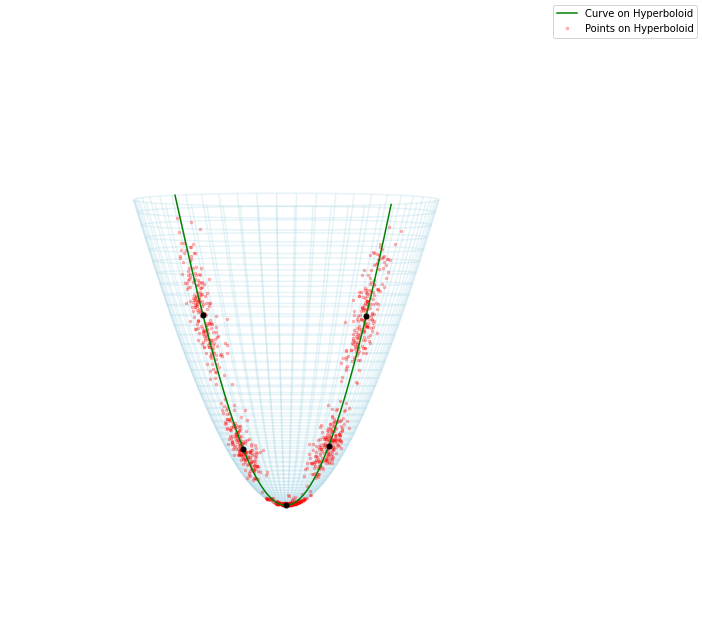

In [264]:
#For hyperboloid
u = np.linspace(0, 1, 1000)
v = np.linspace(0, 2*np.pi, 1000)

u, v = np.meshgrid(u, v)

x_grid = np.cosh(np.abs(u))
y_grid = np.sinh(np.abs(u)) * np.sign(u) * np.cos(v)
z_grid = np.sinh(np.abs(u)) * np.sign(u) * np.sin(v)

# Define the parameter theta
theta = np.linspace(-1, 1, 10000)

# Generate 10 random unit vectors in R2
mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2

fig=plt.figure()
fig.set_size_inches(12, 10)
ax=plt.axes(projection='3d', computed_zorder=False)

x_curve = np.cosh(np.abs(theta))
y_curve = np.sinh(np.abs(theta)) * np.sign(theta) * mu[0]
z_curve = np.sinh(np.abs(theta)) * np.sign(theta) * mu[1]
ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)
# ax.plot_surface(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)

ax.plot(x_curve, y_curve, z_curve, color='green', label='Curve on Hyperboloid', zorder = 1)

# Centers
ax.plot(hyp_points['V1'], hyp_points['V2'], hyp_points['V3'], color='red', marker = '.', lw = 0, markersize = 5, label='Points on Hyperboloid', alpha = 0.25, zorder = 0)

ax.plot(np.cosh(0.8), np.sinh(0.8) * mu[0], np.sinh(0.8) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0.45), np.sinh(0.45) * mu[0], np.sinh(0.45) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0), np.sinh(0) * mu[0], np.sinh(0) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0.45), -np.sinh(0.45) * mu[0], -np.sinh(0.45) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0.8), -np.sinh(0.8) * mu[0], -np.sinh(0.8) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
#ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)

ax.view_init(elev = 90, azim = 0, roll = 180)
ax.grid(False)
ax.set_axis_off()
fig.legend()
plt.show()

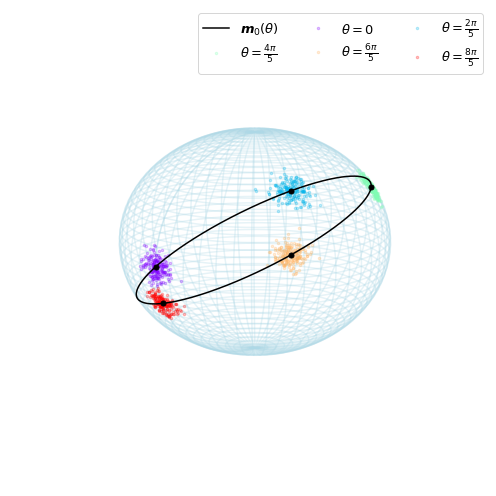

In [12]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import vonmises_fisher

# Function defining the regression mean m_0(theta) on S^2
def m_0(theta, mu):
    """
    Compute the regression mean on S^2.
    
    Parameters:
    theta : array-like
        Angles in [0, 2pi) that parameterize the great circle.
    mu : array-like, shape (2,)
        A unit vector defining the orientation of the great circle.
    
    Returns:
    array, shape (n, 3)
        The mean directions on S^2.
    """
    theta = np.asarray(theta)
    mu = np.asarray(mu)
    assert mu.shape == (2,) and np.isclose(np.linalg.norm(mu), 1), "mu must be a unit vector in R^2"
    
    x1 = np.cos(theta)
    x2 = np.sin(theta) * mu[0]
    x3 = np.sin(theta) * mu[1]
    
    return np.column_stack((x1, x2, x3))

# Function to generate vMF samples
def simulate_data(kappa, mu, theta_samples):
    """
    Generate samples from the von Mises-Fisher distribution on S^2.
    
    Parameters:
    sample_size : int
        Number of samples to generate.
    kappa : float
        Concentration parameter of the vMF distribution.
    mu : array-like, shape (2,)
        The unit vector defining the great circle.
    
    Returns:
    dict
        A dictionary containing input angles and generated samples.
    """
    mean_directions = m_0(theta_samples, mu)  # Compute means on S^2
    
    samples = [vonmises_fisher(mean, kappa).rvs(200) for mean in mean_directions]
    
    return theta_samples, np.array(samples)

mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2

# Create directory for saving samples
save_folder = os.path.join(os.getcwd(), 'simulations_sphere', 'data')
os.makedirs(save_folder, exist_ok=True)

np.random.seed(1000)
sample_size = 1000
kappa = 200
theta_centers = np.array([0, 2*np.pi/5, 4*np.pi/5, 6*np.pi/5, 8*np.pi/5])  # Random angles
theta, Y = simulate_data(kappa, mu, theta_centers)
Y = Y.reshape(-1, 3)

theta_samples = np.linspace(0, 2*np.pi, 1000)

# Plotting the unit sphere
fig=plt.figure()
fig.set_size_inches(7, 7)
ax=plt.axes(projection='3d', computed_zorder=False)

# Create a mesh grid for the unit sphere
u = np.linspace(0, np.pi, 100)
v = np.linspace(0, 2 * np.pi, 100)
u, v = np.meshgrid(u, v)

x_sphere = np.sin(u) * np.cos(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(u)

ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.3, zorder = 0)

curve = m_0(theta_samples, mu)

ax.plot(curve[:,0], curve[:,1], curve[:,2], color='black', label=r'$\boldsymbol{m}_0(\theta)$', zorder = 1)

# Plot the sphere surface

# Plot the von Mises-Fisher samples on the sphere
# add color rainbow palette so that the first each consecutive 200 points have the same color
cmap = plt.cm.rainbow
0, 2*np.pi/5, 4*np.pi/5, 6*np.pi/5, 8*np.pi/5
for i in range(5):
    color = cmap(i/4)
    if i == 0:
        p = f'$\\theta=0$'
    elif i == 1:
        p = f'$\\theta=\\frac{{2\pi}}{{5}}$'
    elif i == 2:
        p = f'$\\theta=\\frac{{4\pi}}{{5}}$'
    elif i == 3:
        p = f'$\\theta=\\frac{{6\pi}}{{5}}$'
    else:
        p = f'$\\theta=\\frac{{8\pi}}{{5}}$'
    color = cmap(i/4)
    ax.plot(Y[i*200:(i+1)*200, 0], Y[i*200:(i+1)*200, 1], Y[i*200:(i+1)*200, 2], marker = '.', color = color, lw = 0, markersize = 5, label = p, alpha = 0.25, zorder = 0)
    
# ax.plot(Y[:, 0], Y[:, 1], Y[:, 2], marker = '.', color='red', lw = 0, markersize = 5, label='Points on Hyperboloid', alpha = 0.25, zorder = 0)

ax.plot(np.cos(theta), np.sin(theta) * mu[0], np.sin(theta) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)

ax.view_init(elev=15, azim=45)  # Adjust view angle
ax.grid(False)
ax.set_axis_off()
fig.tight_layout()
# fig.subplots_adjust(top=1, bottom=0, left=-1, right=1)
h, l = ax.get_legend_handles_labels()
ax.legend(reorder(h, 3), [label for label in reorder(l, 3)], ncol=3, loc='upper right', fontsize=13)
fig.savefig(os.getcwd() + '/simulations_H2/dibujo/sphere_curve_one.pdf', bbox_inches='tight', format='pdf', transparent=True)
plt.show()

### SPD matrices

In [11]:
from scipy.special import digamma
# Define the matrices to interpolate
Sigma_1 = np.array([[1, -0.6],
                  [-0.6, 0.5]])
Sigma_2 = np.array([[1, 0],
                  [0, 1]])
Sigma_3 = np.array([[0.5, 0.4],
                  [0.4, 1]])

Sigmas = (Sigma_1, Sigma_2, Sigma_3)

def Sigma_t(t_array, Sigma_array):
    """Provides an array with the matrices given by a regression model that interpolates between four matrices."""  
    """The regression starts with Sigma_1 and then goes to Sigma_2 and Sigma_3 and ends in Sigma_4."""
    
    # Define time intervals for interpolation
    t_array = np.array(t_array)
    t_array = t_array[:, None, None]

    # Return the interpolated matrices
    return np.where(t_array < 0.5, np.cos(np.pi*t_array)**2 * Sigma_array[0] + (1 - np.cos(np.pi*(1-t_array))**2) * Sigma_array[1], 0) + np.where(t_array >= 0.5, (1 - np.cos(np.pi*t_array)**2) * Sigma_array[1] + np.cos(np.pi*(1-t_array))**2 * Sigma_array[2], 0)

def sim_regression_matrices(Sigmas: tuple,
                            t: np.array,
                            df: int=2):
    t = np.array(t)
    
    #Simulate the time for regression (sample_t) and the true time (true_t)
    q = Sigmas[0].shape[0]

    c_dq = 2 * np.exp((1 / q) * sum( digamma((df - np.arange(1, q + 1) + 1 ) / 2) ))
    sigma_t = Sigma_t(t, Sigmas)
    sample_Y = [wishart( df=df, scale = sigma_t[k] / c_dq ).rvs( size=1 ) for k in range(t.shape[0])]
    return {'t': t, 'y': sample_Y}

In [12]:
q = 2
df = 2
c_dq = 2 * np.exp((1 / q) * sum( digamma((df - np.arange(1, q + 1) + 1 ) / 2) ))
sample = sim_regression_matrices(Sigmas = Sigmas, t = np.linspace(start=0, stop=1, num=11), df=2)

In [15]:
def plot_ellipse(mat: np.ndarray, ax, 
                 xy: tuple=(0,0),
                 scale_factor=1,
                 edgecolor='red',
                 facecolor='None',
                 linewidth=2,
                 alpha=1):
    eigenvalues, eigenvectors = np.linalg.eig(mat)
    theta = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    ellipse = Ellipse(xy=xy,
                  width=scale_factor*np.sqrt(eigenvalues[0]),
                  height=scale_factor*np.sqrt(eigenvalues[1]),
                  angle=theta,
                  edgecolor=edgecolor,
                  facecolor=facecolor,
                  lw=linewidth,
                  alpha=alpha)
    ax.add_patch(ellipse)
color_palette=get_cmap('hsv')

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_50820/1881682009.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_palette=get_cmap('hsv')


/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_50820/2153981264.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_palette=get_cmap('hsv')


NameError: name 'predicted_curve' is not defined

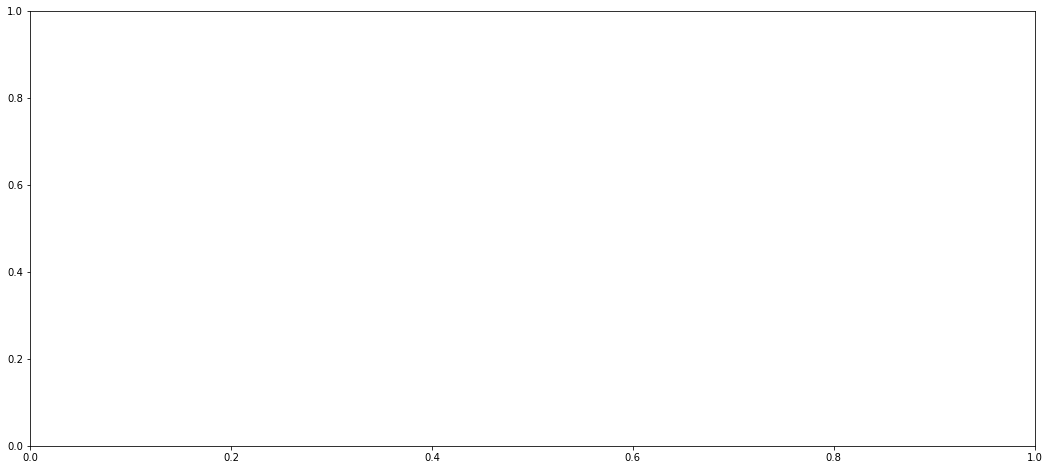

In [16]:
df=2 # Degrees of freedom of the original Wishar distribution

fig, ax=plt.subplots(figsize=(18,8))
color_palette=get_cmap('hsv')
indices_to_plot=list(range(0, len(predicted_curve), 10))
# indices_to_plot.append(len(predicted_curve)-1)
for i in indices_to_plot:
    plot_ellipse(predicted_curve[i], ax=ax, xy=(i/50,0), scale_factor=1/5,
                 edgecolor=color_palette(i))
    plot_ellipse(sample['true'][1][i], ax=ax, xy=(i/50,0.5), scale_factor=1/5,
                 edgecolor=color_palette(i))
    for k in range(30):
        plot_ellipse((1/df)*wishart(df=df, scale=Sigma_true(sample['true'][0][i], Sigmas=(Sigma_1, Sigma_2, Sigma_3))).rvs(size=1), 
                     ax=ax, xy=(i/50,0.5), scale_factor=1/5, edgecolor=color_palette(i), alpha=0.1)
        plot_ellipse((1/df)*wishart(df=df, scale=predicted_curve[i]).rvs(size=1), 
                     ax=ax, xy=(i/50,0), scale_factor=1/5, edgecolor=color_palette(i), alpha=0.05)
    # plot_ellipse((1/df)*sample['true'][1][i], ax=ax, xy=(i/50,0.2), scale_factor=1/10,
    #              edgecolor=color_palette(i))
ax.set_aspect('equal', 'box')
xlim=2
ylim=0.5
plt.xlim(-0.2,4.0)
plt.ylim(-0.2,0.8)
plt.grid(True)
# plt.title('True curve (top row) and predicted (bottom row)')
plt.xticks([])
plt.yticks([])
plt.axhline(y=0, linestyle='dashed', color='black', linewidth=0.5)
plt.axhline(y=0.5, linestyle='dashed', color='black', linewidth=0.5)
plt.show()

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_50820/649494818.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_palette=get_cmap('hsv')


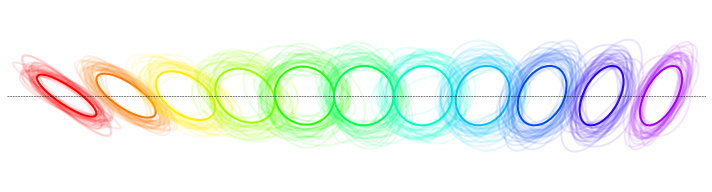

In [22]:
df= 15 # Degrees of freedom of the original Wishar distribution
np.random.seed(1000)
fig, ax=plt.subplots(figsize=(10,8))
color_palette=get_cmap('hsv')
for i in range(11):
    #plot_ellipse(predicted_curve[i], ax=ax, xy=(i/50,0), scale_factor=1/5,
    #             edgecolor=color_palette(i))
    true_Sigma = Sigma_t(t_array = np.array([sample['t'][i]]), Sigma_array=Sigmas)[0]
    plot_ellipse(true_Sigma, ax=ax, xy=(20*i/100, 0.5), scale_factor=1/5,
                 edgecolor=color_palette(20*i))
    for k in range(30):
        plot_ellipse((1/df)*wishart(df=df, scale= 1/c_dq * true_Sigma ).rvs(size=1), 
                     ax=ax, xy=(20*i/100, 0.5), scale_factor=1/5, edgecolor=color_palette(20*i), alpha=0.1)
        #plot_ellipse((1/df)*wishart(df=df, scale=predicted_curve[i]).rvs(size=1), 
        #             ax=ax, xy=(i/50,0), scale_factor=1/5, edgecolor=color_palette(i), alpha=0.05)
    # plot_ellipse((1/df)*sample['true'][1][i], ax=ax, xy=(i/50,0.2), scale_factor=1/10,
    #              edgecolor=color_palette(i))
ax.set_aspect('equal', 'box')
fig.set_size_inches(10, 6)
ax.set_xlim(-0.2 ,2.15)
ax.set_ylim(0.2,0.8)
ax.grid(False)
# plt.title('True curve (top row) and predicted (bottom row)')
ax.set_xticks([])
ax.set_yticks([])
ax.set_axis_off()

fig.tight_layout()

# plt.axhline(y=0, linestyle='dashed', color='black', linewidth=0.5)
ax.axhline(y=0.5, linestyle='dashed', color='black', linewidth=0.5)
fig.savefig(os.getcwd() + '/simulations_SPD/SPD_interpolation_plot.pdf', bbox_inches='tight', format='pdf', transparent=True)
plt.show()